# Tarea 1 Inteligencia Artificial - Parte 2
#### Magdalena Correa - Martin Melo


Se trabajará con el dataset **Appliances Energy Prediction**,
que contiene mediciones del consumo energético de electrodomésticos, iluminación
y condiciones ambientales de una vivienda, registradas cada 10 minutos. El objetivo
es analizar la evolución temporal del consumo mediante cadenas de Markov y
posteriormente inferir su comportamiento utilizando modelos ocultos de Markov
(HMM). El consumo registrado en la variable Appliances deberá clasificarse en seis
estados: muy bajo, bajo, medio-bajo, medio-alto, alto y muy alto. Para construir las
observaciones del HMM, considere la variable lights y los siguientes índices:

$$I_{\text{temperatura}} = \frac{T_1 + T_2 + T_3}{3}, \qquad I_{\text{humedad}} = \frac{RH_1 + RH_2 + RH_3}{3}$$

## Importaciones

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from hmmlearn.hmm import CategoricalHMM

## Parte a - Definición de los 6 estados de consumo, de las 27 observaciones y separación cronológica:

In [38]:
df = pd.read_csv("Dataset/energydata_complete.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
print(df["date"].min(), "->", df["date"].max())
print("nulos:", df.isna().sum().sum())
df.head()

(19735, 29)
2016-01-11 17:00:00 -> 2016-05-27 18:00:00
nulos: 0


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [39]:
saltos = df["date"].diff().dropna()
print(saltos.value_counts())

date
0 days 00:10:00    19734
Name: count, dtype: int64


### Los 6 estados de consumo

Antes de elegir los cortes se observa cómo se distribuye *Appliances*.

In [40]:
print(df["Appliances"].describe())
print()
print("valores distintos:", df["Appliances"].nunique())
print("los 8 más frecuentes (%):")
print((df["Appliances"].value_counts(normalize=True).head(8) * 100).round(2))

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

valores distintos: 92
los 8 más frecuentes (%):
Appliances
50     22.13
60     16.63
40     10.23
70      7.90
80      6.11
90      5.14
100     4.96
110     3.73
Name: proportion, dtype: float64


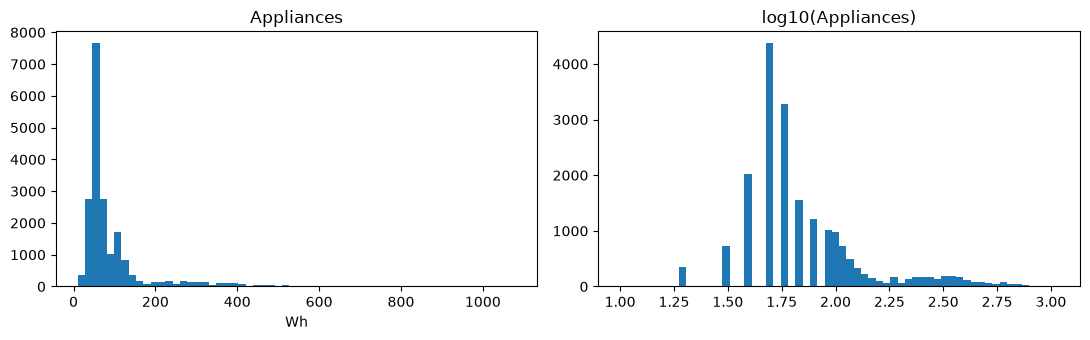

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df["Appliances"], bins=60)
ax[0].set_title("Appliances")
ax[0].set_xlabel("Wh")
ax[1].hist(np.log10(df["Appliances"]), bins=60)
ax[1].set_title("log10(Appliances)")
plt.tight_layout()
plt.show()

In [42]:
# Lo primero que probé fue cortar por sextiles, pero no se puede
try:
    pd.qcut(df["Appliances"], 6)
except ValueError as e:
    print("Falla:", e)

# Y cortando en 6 intervalos de igual ancho queda casi todo en la primera clase
print()
print(pd.cut(df["Appliances"], 6).value_counts().sort_index())

Falla: Bin edges must be unique: Index([10.0, 50.0, 50.0, 60.0, 80.0, 120.0, 1080.0], dtype='float64', name='Appliances').
You can drop duplicate edges by setting the 'duplicates' kwarg

Appliances
(8.93, 188.333]       17675
(188.333, 366.667]     1310
(366.667, 545.0]        520
(545.0, 723.333]        184
(723.333, 901.667]       43
(901.667, 1080.0]         3
Name: count, dtype: int64


Como la variable está muy cargada hacia valores bajos, se terminó usando umbrales fijos
apoyados en los percentiles y en que los valores son múltiplos de 10.

In [43]:
estados = ["muy bajo", "bajo", "medio-bajo", "medio-alto", "alto", "muy alto"]
cortes = [0, 40, 50, 70, 110, 200, np.inf]

df["estado_nombre"] = pd.cut(df["Appliances"], bins=cortes, labels=estados, include_lowest=True)
df["estado"] = df["estado_nombre"].cat.codes

resumen = df.groupby("estado_nombre", observed=False)["Appliances"].agg(["count", "min", "max"])
resumen["%"] = (resumen["count"] / len(df) * 100).round(2)
resumen

,count,min,max,%
estado_nombre,,,,
muy bajo,3094,10,40,15.68
bajo,4368,50,50,22.13
medio-bajo,4842,60,70,24.54
medio-alto,3934,80,110,19.93
alto,1581,120,200,8.01
muy alto,1916,210,1080,9.71


La distribución de Appliances es fuertemente asimétrica (coeficiente 3,39; media 97,69 frente a mediana 60) y solo seis valores concentran el 68,14% de las mediciones. Por eso la discretización por cuantiles falla. Los percentiles 16,7 y 33,3 caen ambos en 50 Wh, así que dos cortes coinciden y no se pueden formar seis intervalos. Los intervalos de ancho constante tampoco sirven, porque dejan el 89,56% de los datos en el primer bin y solo 3 registros en el último, insuficientes para estimar una fila de la matriz de transición. Se optó por los umbrales fijos [0, 40, 50, 70, 110, 200, inf].

### Los índices ambientales y lights

$$I_{\text{temperatura}} = \frac{T_1 + T_2 + T_3}{3}, \qquad I_{\text{humedad}} = \frac{RH_1 + RH_2 + RH_3}{3}$$

In [44]:
df["I_temp"] = df[["T1", "T2", "T3"]].mean(axis=1)
df["I_hum"] = df[["RH_1", "RH_2", "RH_3"]].mean(axis=1)

print(df[["I_temp", "I_hum"]].describe().round(2))
print()
print("lights (%):")
print((df["lights"].value_counts(normalize=True).sort_index() * 100).round(2))

         I_temp     I_hum
count  19735.00  19735.00
mean      21.43     39.97
std        1.81      3.47
min       16.70     26.55
25%       20.26     37.41
50%       21.20     39.58
75%       22.41     42.46
max       27.42     51.89

lights (%):
lights
0     77.28
10    11.21
20     8.23
30     2.83
40     0.39
50     0.05
60     0.01
70     0.01
Name: proportion, dtype: float64


### Separación cronológica

Corte en el 80% de los registros. Se realiza antes de calcular los terciles de los índices, para que los umbrales salgan solo del tramo de entrenamiento y no use información del futuro.

In [45]:
n_corte = int(len(df) * 0.8)
es_train = df.index < n_corte

print("train:", es_train.sum(), "|", df.loc[es_train, "date"].min(), "->", df.loc[es_train, "date"].max())
print("test: ", (~es_train).sum(), "|", df.loc[~es_train, "date"].min(), "->", df.loc[~es_train, "date"].max())

train: 15788 | 2016-01-11 17:00:00 -> 2016-04-30 08:10:00
test:  3947 | 2016-04-30 08:20:00 -> 2016-05-27 18:00:00


In [46]:
# Terciles calculados solo con train
t1, t2 = df.loc[es_train, "I_temp"].quantile([1/3, 2/3])
h1, h2 = df.loc[es_train, "I_hum"].quantile([1/3, 2/3])
print(f"temperatura: baja <= {t1:.2f} < media <= {t2:.2f} < alta")
print(f"humedad:     baja <= {h1:.2f} < media <= {h2:.2f} < alta")

df["n_temp"] = np.where(df["I_temp"] <= t1, 0, np.where(df["I_temp"] <= t2, 1, 2))
df["n_hum"] = np.where(df["I_hum"] <= h1, 0, np.where(df["I_hum"] <= h2, 1, 2))

# lights: apagada / consumo bajo / consumo alto
df["n_lights"] = np.where(df["lights"] == 0, 0, np.where(df["lights"] <= 20, 1, 2))

for col in ["n_temp", "n_hum", "n_lights"]:
    print(col, (df[col].value_counts(normalize=True).sort_index() * 100).round(2).to_dict())

temperatura: baja <= 20.35 < media <= 21.36 < alta
humedad:     baja <= 38.33 < media <= 41.39 < alta
n_temp {0: 26.75, 1: 27.5, 2: 45.75}
n_hum {0: 35.0, 1: 31.56, 2: 33.44}
n_lights {0: 77.28, 1: 19.44, 2: 3.28}


Los terciles de temperatura y humedad se calcularon únicamente sobre el tramo de entrenamiento, para evitar que información del periodo de evaluación influyera en los umbrales. Esta decisión tiene un costo visible, como el tramo de evaluación corresponde a mayo y la temperatura media sube 2,35 °C respecto de abril, el 96,07% de sus registros cae en el nivel alto. En cuanto a la cobertura del alfabeto, las 27 combinaciones posibles (3×3×3) aparecen en los datos, y ninguna observación del conjunto de evaluación está ausente del de entrenamiento, de modo que el modelo no enfrentará observaciones sin frecuencia estimada. Nueve de esas combinaciones representan menos del 1% cada una. La iluminación permanece apagada el 77,28% del tiempo, y el 96,72% acumulado se alcanza en los 20 Wh.

### Las 27 observaciones

Se codificó la tripleta en un solo número: $o = 9 \cdot temp + 3 \cdot hum + lights$, entre 0 y 26.

In [47]:
df["obs"] = 9 * df["n_temp"] + 3 * df["n_hum"] + df["n_lights"]

print("observaciones distintas:", df["obs"].nunique(), "de 27")
print("nunca observadas:", sorted(set(range(27)) - set(df["obs"].unique())))

# Tabla de las 27 combinaciones para tenerla de referencia
nombres_t = ["temp baja", "temp media", "temp alta"]
nombres_h = ["hum baja", "hum media", "hum alta"]
nombres_l = ["apagada", "luz baja", "luz alta"]

catalogo = pd.DataFrame([(o, nombres_t[o // 9], nombres_h[(o % 9) // 3], nombres_l[o % 3])
                         for o in range(27)],
                        columns=["codigo", "temperatura", "humedad", "lights"])
catalogo["frecuencia"] = catalogo["codigo"].map(df["obs"].value_counts())
catalogo

observaciones distintas: 27 de 27
nunca observadas: []


,codigo,temperatura,humedad,lights,frecuencia
0,0,temp baja,hum baja,apagada,1655
1,1,temp baja,hum baja,luz baja,389
2,2,temp baja,hum baja,luz alta,40
3,3,temp baja,hum media,apagada,1282
4,4,temp baja,hum media,luz baja,348
5,5,temp baja,hum media,luz alta,57
6,6,temp baja,hum alta,apagada,1166
7,7,temp baja,hum alta,luz baja,273
8,8,temp baja,hum alta,luz alta,69
9,9,temp media,hum baja,apagada,1481


In [48]:
cols = ["date", "Appliances", "estado", "estado_nombre", "obs"]
train = df.loc[es_train, cols].reset_index(drop=True)
test = df.loc[~es_train, cols].reset_index(drop=True)

train["dia"] = train["date"].dt.date
test["dia"] = test["date"].dt.date

print("no hay solapamiento:", train["date"].max() < test["date"].min())
print("obs de test que no están en train:", sorted(set(test["obs"]) - set(train["obs"])))
print()
print(pd.DataFrame({
    "train %": train["estado_nombre"].value_counts(normalize=True).reindex(estados) * 100,
    "test %": test["estado_nombre"].value_counts(normalize=True).reindex(estados) * 100,
}).round(2))

no hay solapamiento: True
obs de test que no están en train: []

               train %  test %
estado_nombre                 
muy bajo         18.29    5.22
bajo             22.05   22.45
medio-bajo       22.62   32.20
medio-alto       18.98   23.76
alto              7.98    8.13
muy alto         10.08    8.23


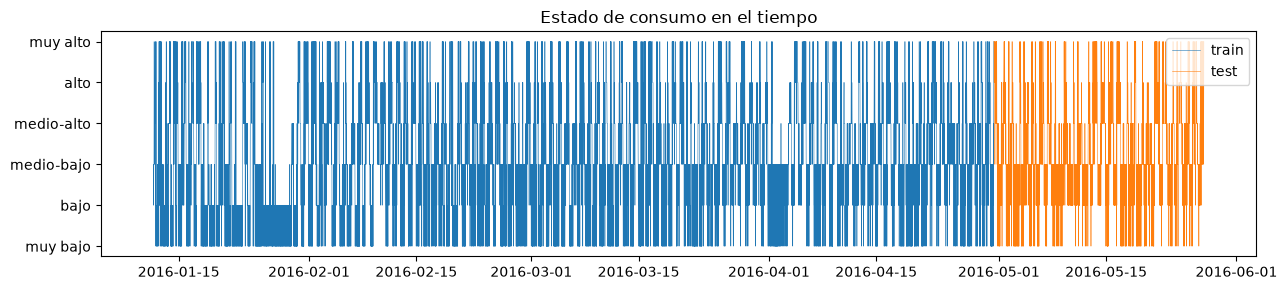

In [49]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(train["date"], train["estado"], lw=0.4, label="train")
ax.plot(test["date"], test["estado"], lw=0.4, label="test")
ax.set_yticks(range(6))
ax.set_yticklabels(estados)
ax.legend()
ax.set_title("Estado de consumo en el tiempo")
plt.tight_layout()
plt.show()

El muestreo del dataset es regular cada 10 minutos, sin vacíos ni registros duplicados. La división cronológica 80/20, en cambio, introduce un desplazamiento estacional entre ambos tramos, como el conjunto de evaluación corresponde a mayo, la temperatura media pasa de 21,70 °C en abril a 24,05 °C, y el nivel de temperatura "alta" salta de 33,17% en entrenamiento a 96,07% en evaluación. El consumo medio mensual se mantiene estable a lo largo de todo el periodo, con variaciones menores al 5%, pero la distribución de los estados sí cambia a "muy bajo" y cae de 18,29% a 5,22%, una diferencia de 13,07 puntos porcentuales que equivale a una reducción del 71%, mientras "medio-bajo" sube 9,58 puntos.


# (b) Las dos cadenas de Markov

Construir dos cadenas de Markov: una considerando todos los registros
como una secuencia continua y otra considerando cada día como una
secuencia independiente. Estimar mediante conteos las matrices de
transición correspondientes. Para el modelo continuo, utilizar su distribución
estacionaria como distribución inicial; para el modelo diario, estimar la
distribución inicial a partir del primer estado de cada jornada.


In [50]:
# reviso si hay días incompletos (deberían ser 144 registros por día)
largos = train.groupby("dia").size()
print(largos[largos != 144])
print("días completos:", (largos == 144).sum(), "de", len(largos))

dia
2016-01-11    42
2016-04-30    50
dtype: int64
días completos: 109 de 111


Se descartan los dos días incompletos del modelo diario, así todas las secuencias son comparables.

In [51]:
def contar_transiciones(secuencias):
    C = np.zeros((6, 6))
    for s in secuencias:
        for i, j in zip(s[:-1], s[1:]):
            C[i, j] += 1
    return C

# Modelo continuo: una sola secuencia
sec_continua = [train["estado"].to_numpy()]

# Modelo diario: una secuencia por día completo
sec_diarias = [g["estado"].to_numpy() for _, g in train.groupby("dia") if len(g) == 144]

C_cont = contar_transiciones(sec_continua)
C_dia = contar_transiciones(sec_diarias)

A_cont = (C_cont + 1) / (C_cont + 1).sum(axis=1, keepdims=True)
A_dia = (C_dia + 1) / (C_dia + 1).sum(axis=1, keepdims=True)

print("transiciones continuo:", int(C_cont.sum()))
print("transiciones diario:  ", int(C_dia.sum()), f"({len(sec_diarias)} días)")
print("celdas en cero:", int((C_cont == 0).sum()), "/", int((C_dia == 0).sum()))

transiciones continuo: 15787
transiciones diario:   15587 (109 días)
celdas en cero: 0 / 0


In [52]:
print("A continuo")
display(pd.DataFrame(A_cont.round(4), index=estados, columns=estados))
print("\nA diario")
display(pd.DataFrame(A_dia.round(4), index=estados, columns=estados))
print("\ndiferencia máxima:", round(abs(A_cont - A_dia).max(), 5))

A continuo


,muy bajo,bajo,medio-bajo,medio-alto,alto,muy alto
muy bajo,0.5729,0.3020,0.1026,0.0135,0.0041,0.0048
bajo,0.2595,0.4432,0.2661,0.0183,0.0063,0.0066
medio-bajo,0.0808,0.2678,0.4904,0.1238,0.0168,0.0204
medio-alto,0.0093,0.0250,0.1642,0.6462,0.1103,0.0450
alto,0.0071,0.0182,0.0513,0.2938,0.4613,0.1682
muy alto,0.0031,0.0075,0.0244,0.0902,0.1610,0.7137



A diario


,muy bajo,bajo,medio-bajo,medio-alto,alto,muy alto
muy bajo,0.5742,0.3013,0.1017,0.0137,0.0042,0.0049
bajo,0.2594,0.4440,0.2649,0.0186,0.0064,0.0067
medio-bajo,0.0816,0.2661,0.4890,0.1259,0.0171,0.0203
medio-alto,0.0094,0.0248,0.1642,0.6461,0.1106,0.0449
alto,0.0071,0.0182,0.0515,0.2940,0.4612,0.1680
muy alto,0.0031,0.0076,0.0239,0.0901,0.1618,0.7135



diferencia máxima: 0.00205


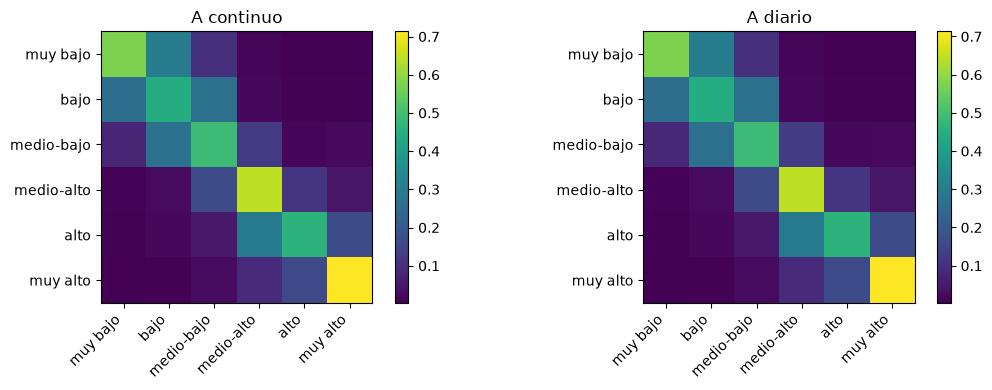

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for e, (M, t) in zip(ax, [(A_cont, "A continuo"), (A_dia, "A diario")]):
    im = e.imshow(M)
    e.set_xticks(range(6)); e.set_xticklabels(estados, rotation=45, ha="right")
    e.set_yticks(range(6)); e.set_yticklabels(estados)
    e.set_title(t)
    fig.colorbar(im, ax=e, fraction=0.046)
plt.tight_layout()
plt.show()

### Distribuciones iniciales

Para el modelo continuo se utilizó la estacionaria, que sale del vector propio izquierdo de A asociado al valor propio 1. Para el diario se cuenta del primer estado de cada jornada.

In [54]:
valores, vectores = np.linalg.eig(A_cont.T)
k = np.argmin(np.abs(valores - 1))
pi_cont = np.real(vectores[:, k])
pi_cont = pi_cont / pi_cont.sum()

print("estacionaria:", pi_cont.round(4))
print("se cumple pi = pi A:", np.allclose(np.dot(pi_cont, A_cont), pi_cont))

estacionaria: [0.1828 0.2203 0.2259 0.1898 0.0801 0.1011]
se cumple pi = pi A: True


In [55]:
primeros = np.array([s[0] for s in sec_diarias])
conteo = np.bincount(primeros, minlength=6) + 1
pi_dia = conteo / conteo.sum()

pd.DataFrame({
    "estacionaria": pi_cont.round(4),
    "inicial diaria": pi_dia.round(4),
    "frecuencia en train": train["estado"].value_counts(normalize=True).sort_index().round(4).values,
}, index=estados)

,estacionaria,inicial diaria,frecuencia en train
muy bajo,0.1828,0.2087,0.1829
bajo,0.2203,0.3565,0.2205
medio-bajo,0.2259,0.3913,0.2262
medio-alto,0.1898,0.0174,0.1898
alto,0.0801,0.0087,0.0798
muy alto,0.1011,0.0174,0.1008


Ambas matrices presentan una diagonal principal marcada, que refleja la persistencia del estado actual: destacan muy alto (71,37%) y medio-alto (64,62%). Las transiciones ocurren de forma gradual hacia niveles contiguos, y los saltos entre extremos, como de muy bajo a muy alto, no superan el 0,5%. Las dos matrices son casi idénticas, con una diferencia máxima de 0,00205, porque separar las secuencias por jornada solo excluye 200 transiciones del conteo, un 1,27% del total. Usar la distribución estacionaria como condición inicial equivale a suponer que el sistema parte ya en su equilibrio de largo plazo. En el modelo diario resulta más apropiada la distribución empírica de las jornadas, ya que el 95,65% de los días comienza en los tres estados de menor consumo y prácticamente ninguno en estados altos, lo que refleja la rutina real de inicio del día.

# (c) Interpretación y consultas

In [56]:
pd.DataFrame({
    "P(quedarse)": np.diag(A_cont).round(4),
    "duración media (min)": (10 / (1 - np.diag(A_cont))).round(1),
    "peso estacionario": pi_cont.round(4),
}, index=estados)

,P(quedarse),duración media (min),peso estacionario
muy bajo,0.5729,23.4,0.1828
bajo,0.4432,18.0,0.2203
medio-bajo,0.4904,19.6,0.2259
medio-alto,0.6462,28.3,0.1898
alto,0.4613,18.6,0.0801
muy alto,0.7137,34.9,0.1011


### Consulta 1: cuánto dura la memoria de un pico de consumo

Si en este momento el consumo es muy alto, ¿cuál es la probabilidad de seguir en muy alto
después de distintos horizontes?

In [57]:
for pasos in [1, 6, 18, 72, 144]:
    p = np.linalg.matrix_power(A_cont, pasos)[5, 5]
    print(f"{pasos:4d} pasos ({pasos*10/60:5.1f} h): {p:.4f}")

print("\nvalor estacionario de 'muy alto':", round(pi_cont[5], 4))

   1 pasos (  0.2 h): 0.7137
   6 pasos (  1.0 h): 0.2567
  18 pasos (  3.0 h): 0.1177
  72 pasos ( 12.0 h): 0.1011
 144 pasos ( 24.0 h): 0.1011

valor estacionario de 'muy alto': 0.1011


### Consulta 2: desde el consumo más bajo, cuándo se puede llegar a consumo alto


In [58]:
for pasos in [1, 6, 36, 144]:
    p = np.linalg.matrix_power(A_cont, pasos)[0, 4]
    print(f"{pasos:4d} pasos ({pasos*10/60:5.1f} h): {p:.4f}")

print("\nvalor estacionario de 'alto':", round(pi_cont[4], 4))

   1 pasos (  0.2 h): 0.0041
   6 pasos (  1.0 h): 0.0404
  36 pasos (  6.0 h): 0.0799
 144 pasos ( 24.0 h): 0.0801

valor estacionario de 'alto': 0.0801


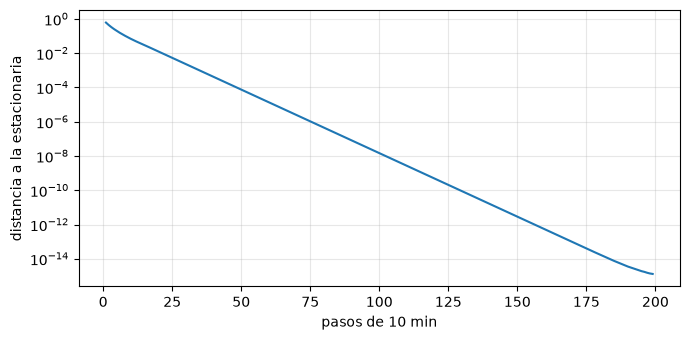

baja de 0.01 en 22 pasos (3.7 h)
baja de 0.001 en 35 pasos (5.8 h)


In [59]:
# Cuánto tarda A^k en parecerse a la estacionaria
ks = np.arange(1, 200)
dist = [abs(np.linalg.matrix_power(A_cont, k) - pi_cont).max() for k in ks]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(ks, dist)
ax.set_xlabel("pasos de 10 min")
ax.set_ylabel("distancia a la estacionaria")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for u in [1e-2, 1e-3]:
    k = int(np.argmax(np.array(dist) < u)) + 1
    print(f"baja de {u} en {k} pasos ({k*10/60:.1f} h)")

### Modelo diario: cómo empiezan y cómo terminan las jornadas


In [60]:
ultimos = np.array([s[-1] for s in sec_diarias])

pd.DataFrame({
    "inicio (n)": np.bincount(primeros, minlength=6),
    "inicio (%)": (np.bincount(primeros, minlength=6) / len(primeros) * 100).round(2),
    "fin (n)": np.bincount(ultimos, minlength=6),
    "fin (%)": (np.bincount(ultimos, minlength=6) / len(ultimos) * 100).round(2),
}, index=estados)

,inicio (n),inicio (%),fin (n),fin (%)
muy bajo,23,21.10,28,25.69
bajo,40,36.70,30,27.52
medio-bajo,44,40.37,47,43.12
medio-alto,1,0.92,3,2.75
alto,0,0.00,1,0.92
muy alto,1,0.92,0,0.00


### Consulta 3: cómo evoluciona el consumo durante la jornada

Se propagó la distribución inicial diaria con la matriz A del modelo diario y se comparó con lo que realmente se observa por hora en el conjunto de entrenamiento.

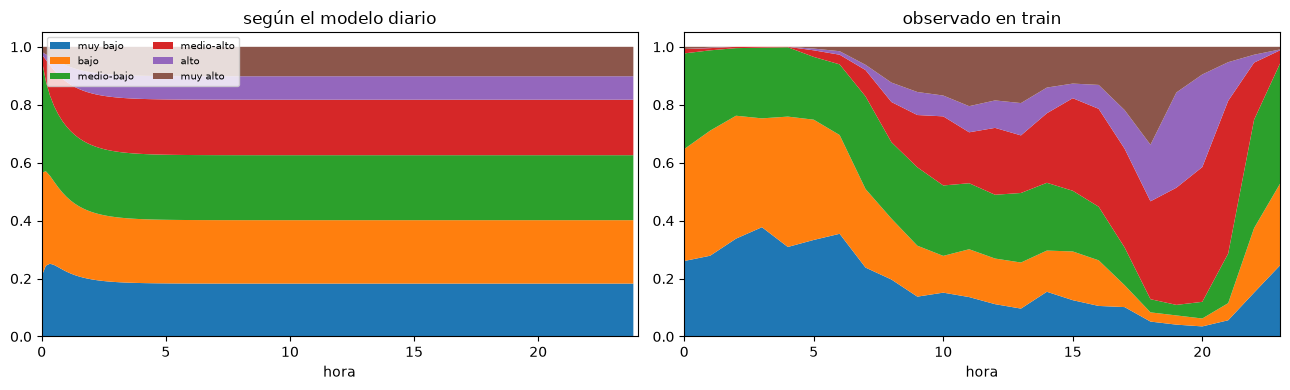

In [61]:
evolucion = np.vstack([pi_dia @ np.linalg.matrix_power(A_dia, k) for k in range(144)])

empirica = train.assign(h=train["date"].dt.hour).groupby(["h", "estado"]).size().unstack(fill_value=0)
empirica = empirica.div(empirica.sum(axis=1), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].stackplot(np.arange(144) / 6, evolucion.T, labels=estados)
ax[0].set_title("según el modelo diario")
ax[0].set_xlabel("hora")
ax[0].set_xlim(0, 24)
ax[0].legend(fontsize=7, loc="upper left", ncol=2)

ax[1].stackplot(empirica.index, empirica.T.values, labels=estados)
ax[1].set_title("observado en train")
ax[1].set_xlabel("hora")
ax[1].set_xlim(0, 23)
plt.tight_layout()
plt.show()

In [62]:
# La distribución a dos horas puntuales del día
for pasos, etiqueta in [(60, "10:00"), (114, "19:00")]:
    d = pi_dia @ np.linalg.matrix_power(A_dia, pasos)
    print(etiqueta, " ".join(f"{estados[i]} {d[i]*100:.1f}%" for i in range(6)))

10:00 muy bajo 18.3% bajo 21.9% medio-bajo 22.4% medio-alto 19.2% alto 8.1% muy alto 10.2%
19:00 muy bajo 18.3% bajo 21.9% medio-bajo 22.4% medio-alto 19.2% alto 8.1% muy alto 10.2%


Los estados presentan duraciones medias muy distintas, muy alto es el más persistente, con 34,9 minutos, y bajo el menos, con 18,0. Sin embargo, esa memoria se pierde rápido. En el modelo diario la distancia a su propia distribución estacionaria baja de 0,001 a las 4,7 horas, de modo que la predicción se aplana y entrega distribuciones idénticas para las 10:00 y las 19:00, con 18,3% en muy bajo y 10,2% en muy alto. La frecuencia observada, en cambio, muestra un patrón circadiano marcado, los consumos bajos se concentran en la madrugada, con 37,7% en muy bajo a las 03:00, y hay un pico al atardecer, cuando a las 19:00 los tres estados superiores reúnen el 89,2% de los registros. Una cadena homogénea de primer orden no puede reproducir esos ciclos.

# (d) Matriz de emisión y los dos HMM

In [63]:
C_emis = np.zeros((6, 27))
for s, o in zip(train["estado"], train["obs"]):
    C_emis[s, o] += 1

B = (C_emis + 1) / (C_emis + 1).sum(axis=1, keepdims=True)

print("registros por estado:", C_emis.sum(axis=1).astype(int))
print("celdas en cero:", int((C_emis == 0).sum()), "de", C_emis.size)
print("filas suman 1:", np.allclose(B.sum(axis=1), 1))

pd.DataFrame(B.round(4), index=estados, columns=[f"o{k}" for k in range(27)]).iloc[:, :13]

registros por estado: [2888 3482 3571 2996 1260 1591]
celdas en cero: 5 de 162
filas suman 1: True


,o0,o1,o2,o3,o4,o5,o6,o7,o8,o9,o10,o11,o12
muy bajo,0.1527,0.0148,0.0014,0.1774,0.0213,0.0010,0.2130,0.0093,0.0003,0.0758,0.0082,0.0010,0.0744
bajo,0.1348,0.0165,0.0009,0.1188,0.0168,0.0006,0.0866,0.0046,0.0011,0.0972,0.0103,0.0003,0.1314
medio-bajo,0.1003,0.0331,0.0036,0.0400,0.0206,0.0044,0.0322,0.0128,0.0039,0.1073,0.0336,0.0039,0.1234
medio-alto,0.0708,0.0291,0.0050,0.0284,0.0192,0.0083,0.0218,0.0185,0.0023,0.0969,0.0420,0.0060,0.0794
alto,0.0474,0.0272,0.0023,0.0210,0.0210,0.0062,0.0148,0.0536,0.0117,0.0513,0.0311,0.0070,0.0591
muy alto,0.0661,0.0321,0.0049,0.0501,0.0457,0.0056,0.0284,0.0402,0.0210,0.0600,0.0185,0.0049,0.0698


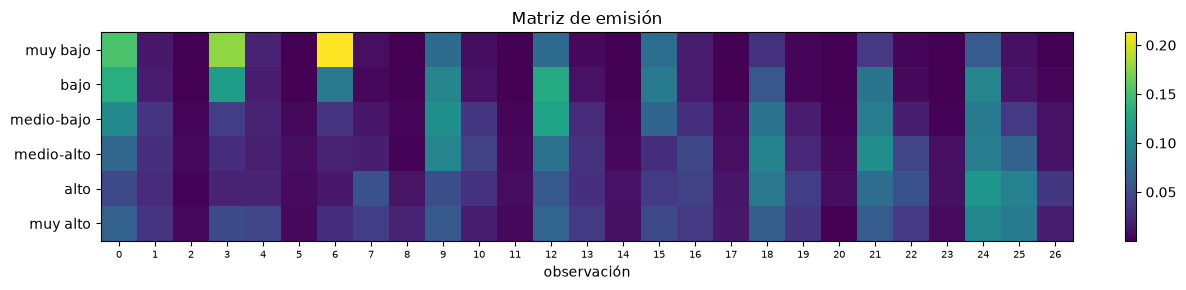

muy bajo     -> obs  6 (temp baja, hum alta, apagada) con P = 0.213
bajo         -> obs  0 (temp baja, hum baja, apagada) con P = 0.135
medio-bajo   -> obs 12 (temp media, hum media, apagada) con P = 0.123
medio-alto   -> obs 21 (temp alta, hum media, apagada) con P = 0.106
alto         -> obs 24 (temp alta, hum alta, apagada) con P = 0.112
muy alto     -> obs 24 (temp alta, hum alta, apagada) con P = 0.098


In [64]:
fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(B, aspect="auto")
ax.set_yticks(range(6))
ax.set_yticklabels(estados)
ax.set_xticks(range(27))
ax.set_xticklabels(range(27), fontsize=7)
ax.set_xlabel("observación")
ax.set_title("Matriz de emisión")
fig.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

# observación más probable de cada estado, para ver si tiene sentido
for i in range(6):
    o = int(B[i].argmax())
    print(f"{estados[i]:12s} -> obs {o:2d} ({nombres_t[o//9]}, {nombres_h[(o%9)//3]}, {nombres_l[o%3]}) "
          f"con P = {B[i, o]:.3f}")

In [65]:
# init_params y params vacíos para que hmmlearn no reestime nada y use mis parámetros
def armar_hmm(pi, A):
    m = CategoricalHMM(n_components=6, n_features=27, init_params="", params="")
    m.startprob_ = pi
    m.transmat_ = A
    m.emissionprob_ = B
    return m

hmm_cont = armar_hmm(pi_cont, A_cont)
hmm_dia = armar_hmm(pi_dia, A_dia)

for nombre, m in [("continuo", hmm_cont), ("diario", hmm_dia)]:
    print(nombre, "| startprob suma", round(m.startprob_.sum(), 6),
          "| transmat ok", np.allclose(m.transmat_.sum(1), 1),
          "| emissionprob ok", np.allclose(m.emissionprob_.sum(1), 1))

continuo | startprob suma 1.0 | transmat ok True | emissionprob ok True
diario | startprob suma 1.0 | transmat ok True | emissionprob ok True


### Análisis de la matriz de emisión

La matriz de emisión se estimó mediante frecuencias relativas sobre el conjunto de entrenamiento, contabilizando la coincidencia de cada estado de consumo con cada una de las 27 observaciones posibles. Los seis estados reúnen entre 1.260 y 3.571 registros, lo que garantiza respaldo muestral para todas las filas de la matriz, siendo el estado *alto* el de menor representación. De las 162 celdas de la matriz, solo 5 registraron un conteo inicial de cero, por lo que se aplicó un **suavizado de Laplace** (sumando 1 a cada celda) para evitar probabilidades nulas que anularían por completo la verosimilitud de una secuencia ante la aparición de dicha combinación.

**La matriz de emisión resulta poco discriminativa.** 

La observación más probable para cada estado presenta una probabilidad de tan solo entre 0,098 y 0,213, muy lejos de concentrar la densidad de masa. Los estados *alto* y *muy alto* comparten la misma observación modal (la N.° 24: temperatura alta, humedad alta e iluminación apagada), con probabilidades de 0,112 y 0,098, respectivamente. Desde la perspectiva de las observaciones, dos estados ocultos distintos con el mismo modo de emisión resultan prácticamente indistinguibles. Asimismo, los seis estados comparten una observación modal donde la iluminación permanece apagada, lo cual es coherente considerando que *lights* es igual a cero en el 77,28% de las mediciones.

Este comportamiento anticipa la limitación estructural del modelo donde las variables ambientales seleccionadas para conformar las observaciones aportan una señal débil sobre el consumo eléctrico de los electrodomésticos. La temperatura y la humedad interiores responden a la estación del año y al clima exterior, no al uso inmediato de artefactos como la cocina o la lavadora. Si bien la iluminación es la única variable ligada de forma directa con la presencia de los ocupantes, permanece inactiva la mayor parte del día.

A pesar de esta limitación, el modelo exhibe cierta coherencia estructural sobre los estados de consumo bajo que emiten preferentemente observaciones de temperatura baja (observaciones 0 y 6) , intermedios emiten observaciones de temperatura media (observación 12) y los estados altos emiten observaciones de temperatura alta (observaciones 21 y 24).

Esta progresión no responde a una relación causal entre la temperatura y el consumo, sino a que ambas variables comparten una causa común de la evolución temporal a lo largo del período de medición (enero a mayo), donde la temperatura interior se eleva progresivamente mientras el patrón de consumo se modifica en paralelo.

### Por qué ambos modelos pueden compartir la misma matriz de emisión

Un Modelo Oculto de Markov (HMM) queda completamente parametrizado por el $(\pi, A, B)$, osea la distribución inicial ($\pi$), la matriz de transición ($A$) y la matriz de emisión ($B$). Los dos primeros componentes describen la dinámica temporal del proceso latente, mientras que la matriz de emisión caracteriza únicamente la manifestación observacional de cada estado.

La propiedad de **independencia condicional** fundamental del HMM establece que:

$$P(O_t \mid q_t, q_{t-1}, \ldots, q_1, O_{t-1}, \ldots, O_1) = P(O_t \mid q_t)$$

Es decir, la observación en el instante $t$ depende exclusivamente del estado en ese mismo instante $q_t$, y es condicionalmente independiente de todo el historial pasado de estados y observaciones. Por lo tanto, la matriz de emisión no contiene ni codifica información sobre la estructura secuencial o la dinámica temporal del proceso.

La diferencia entre el modelo continuo y el modelo diario Consiste en una teoría sobre la forma en que evoluciona algo a lo largo del tiempo y determinar si las transiciones que cruzan la medianoche deben contabilizarse o no. Esta decisión afecta directamente a la matriz de transición $A$, así como a $\pi$ (al modificar la definición del instante inicial), pero no altera la relación estática entre estado y observación representada en $B$.

Existen dos condiciones metodológicas que validan la transferencia de la matriz de emisión entre ambos modelos:

1. **Identidad del espacio de estados y del alfabeto:** Ambos modelos comparten exactamente los mismos seis estados de consumo (definidos bajo los mismos umbrales) y el mismo alfabeto de 27 observaciones discretas.

2. **Identidad del conjunto de entrenamiento:** Ambas matrices $B$ se estiman sobre el mismo conjunto de datos observados. Si los estados se hubieran discretizado de manera distinta en cada modelo, la matriz de emisión no sería transferible, aun cuando la propiedad de independencia condicional se mantuviera.

# (e) Inferencia sobre un día de evaluación

In [66]:
largos_test = test.groupby("dia").size()
dias_completos = list(largos_test[largos_test == 144].index)
print(len(dias_completos), "días completos, de", dias_completos[0], "a", dias_completos[-1])

DIA = dias_completos[0]     # acá puedo cambiar el día

jornada = test[test["dia"] == DIA].reset_index(drop=True)
O = jornada["obs"].to_numpy().reshape(-1, 1)     # hmmlearn pide forma (T, 1)
reales = jornada["estado"].to_numpy()

print("\ndía elegido:", DIA)
print((jornada["estado_nombre"].value_counts(normalize=True).reindex(estados).fillna(0) * 100).round(2))

26 días completos, de 2016-05-01 a 2016-05-26

día elegido: 2016-05-01
estado_nombre
muy bajo       7.64
bajo          20.83
medio-bajo    22.92
medio-alto    30.56
alto           9.72
muy alto       8.33
Name: proportion, dtype: float64


### Forward: probabilidad de las observaciones

In [67]:
for nombre, m in [("continuo", hmm_cont), ("diario", hmm_dia)]:
    logp = m.score(O)
    print(f"{nombre}: log P(O) = {logp:.3f} | por observación = {logp/len(O):.3f} | P(O) = {np.exp(logp):.2e}")

continuo: log P(O) = -352.065 | por observación = -2.445 | P(O) = 1.26e-153
diario: log P(O) = -351.695 | por observación = -2.442 | P(O) = 1.82e-153


### Forward-Backward: probabilidad de cada estado en instantes puntuales

In [68]:
post_cont = hmm_cont.predict_proba(O)
post_dia = hmm_dia.predict_proba(O)

for t in [60, 114]:
    hora = jornada.loc[t, "date"].strftime("%H:%M")
    d = post_dia[t]
    print(f"t = {t} ({hora}) | real: {estados[reales[t]]}")
    print("   " + " ".join(f"{estados[i]} {d[i]*100:.1f}%" for i in range(6)))
    print(f"   el modelo diría: {estados[d.argmax()]}")
    print()

t = int(post_dia[:, 5].argmax())
print("instante más probable de 'muy alto':", jornada.loc[t, "date"].strftime("%H:%M"),
      f"con P = {post_dia[t, 5]:.3f}, y el real era {estados[reales[t]]}")

t = 60 (10:00) | real: muy bajo
   muy bajo 0.6% bajo 3.2% medio-bajo 14.2% medio-alto 56.1% alto 17.6% muy alto 8.4%
   el modelo diría: medio-alto

t = 114 (19:00) | real: alto
   muy bajo 0.2% bajo 1.6% medio-bajo 10.0% medio-alto 52.7% alto 22.5% muy alto 13.0%
   el modelo diría: medio-alto

instante más probable de 'muy alto': 19:10 con P = 0.147, y el real era alto


### Viterbi: la secuencia más probable

In [69]:
logv_cont, vit_cont = hmm_cont.decode(O, algorithm="viterbi")
logv_dia, vit_dia = hmm_dia.decode(O, algorithm="viterbi")

map_cont = post_cont.argmax(axis=1)
map_dia = post_dia.argmax(axis=1)

comparacion = pd.DataFrame({
    "log P(O)": [hmm_cont.score(O), hmm_dia.score(O)],
    "log P(camino)": [logv_cont, logv_dia],
    "acierto Viterbi": [(vit_cont == reales).mean(), (vit_dia == reales).mean()],
    "acierto Forward-Backward": [(map_cont == reales).mean(), (map_dia == reales).mean()],
    "desacuerdo entre ambos": [(vit_cont != map_cont).mean(), (vit_dia != map_dia).mean()],
}, index=["continuo", "diario"]).round(4)
comparacion

,log P(O),log P(camino),acierto Viterbi,acierto Forward-Backward,desacuerdo entre ambos
continuo,-352.0645,-402.2005,0.3819,0.4236,0.2153
diario,-351.6950,-401.7125,0.3819,0.4167,0.2083


In [70]:
for nombre, pred in [("continuo", vit_cont), ("diario", vit_dia)]:
    m = pd.crosstab(pd.Series([estados[i] for i in reales], name="real"),
                    pd.Series([estados[i] for i in pred], name="Viterbi"))
    print(nombre)
    print(m.reindex(index=estados, columns=estados, fill_value=0))
    print()

continuo
Viterbi     muy bajo  bajo  medio-bajo  medio-alto  alto  muy alto
real                                                              
muy bajo           0     0           7           4     0         0
bajo              10     2          14           4     0         0
medio-bajo         5     0          10          18     0         0
medio-alto         1     0           0          43     0         0
alto               0     0           0          14     0         0
muy alto           0     0           0          12     0         0

diario
Viterbi     muy bajo  bajo  medio-bajo  medio-alto  alto  muy alto
real                                                              
muy bajo           0     0           7           4     0         0
bajo              10     2          14           4     0         0
medio-bajo         5     0          10          18     0         0
medio-alto         1     0           0          43     0         0
alto               0     0           0       

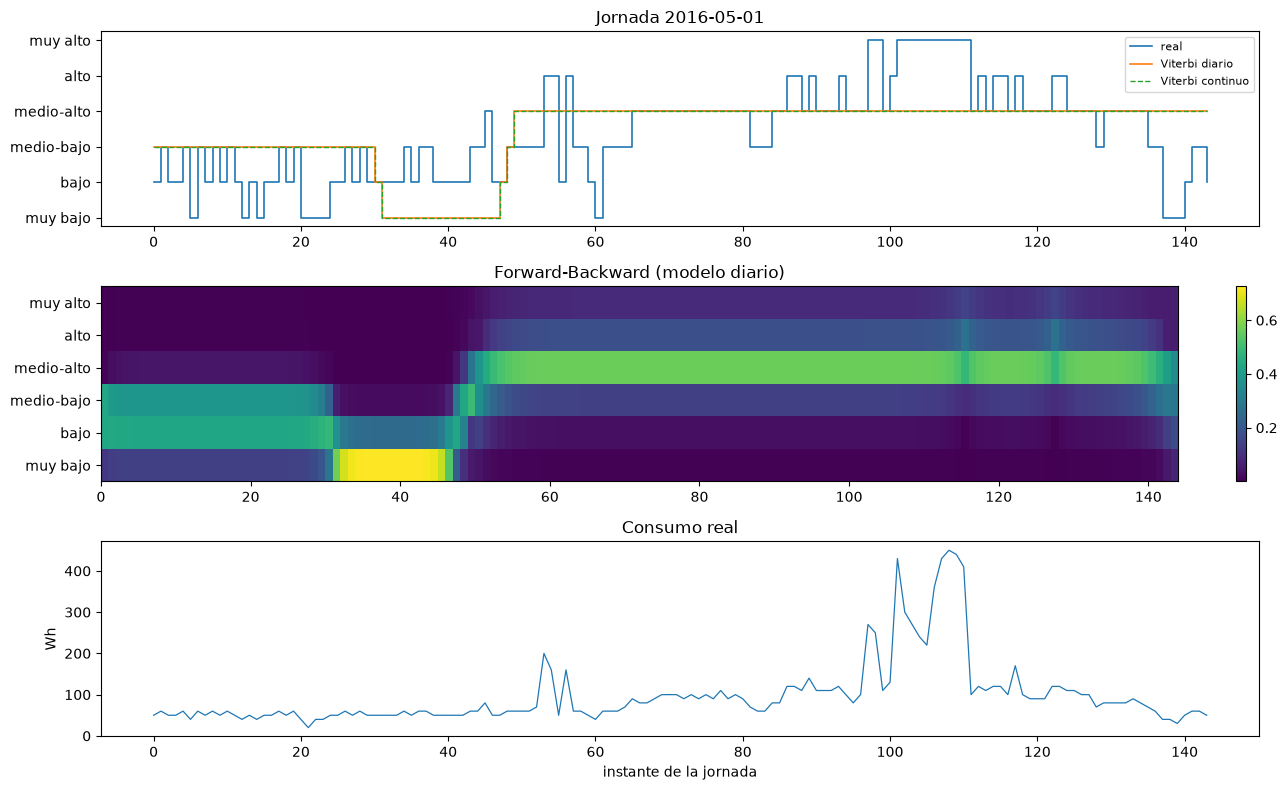

In [71]:
fig, ax = plt.subplots(3, 1, figsize=(13, 8))

ax[0].step(range(len(O)), reales, where="post", lw=1.2, label="real")
ax[0].step(range(len(O)), vit_dia, where="post", lw=1.2, label="Viterbi diario")
ax[0].step(range(len(O)), vit_cont, where="post", lw=1, ls="--", label="Viterbi continuo")
ax[0].set_yticks(range(6)); ax[0].set_yticklabels(estados)
ax[0].legend(fontsize=8); ax[0].set_title(f"Jornada {DIA}")

im = ax[1].imshow(post_dia.T, aspect="auto", origin="lower", extent=[0, len(O), -0.5, 5.5])
ax[1].set_yticks(range(6)); ax[1].set_yticklabels(estados)
ax[1].set_title("Forward-Backward (modelo diario)")
fig.colorbar(im, ax=ax[1], fraction=0.02)

ax[2].plot(jornada["Appliances"].values, lw=0.9)
ax[2].set_ylabel("Wh")
ax[2].set_title("Consumo real")
ax[2].set_xlabel("instante de la jornada")

plt.tight_layout()
plt.show()

### Análisis de las inferencias sobre la jornada del 1 de mayo

**Forward.** 

El modelo continuo asigna a la secuencia observada $\log P(O) = -352,065$ y el modelo diario $\log P(O) = -351,695$, lo que representa 2,44 nats por observación en ambos casos. La diferencia entre modelos es de 0,37 nats sobre las 144 observaciones completas, lo que equivale a que el modelo diario considere la jornada apenas 1,45 veces más probable que el continuo. Como referencia, un modelo que asignara probabilidad uniforme a las 27 observaciones posibles obtendría $\ln(1/27) = -3,296$ por observación, lo que esto confirma que ambos HMM extraen información relevante de los datos, aunque la ganancia respecto al azar sea moderada.

**Forward-Backward.**

Este algoritmo entrega, para cada instante, la distribución de probabilidad posterior sobre los seis estados condicionada a la secuencia completa de observaciones, combinando la evidencia anterior mediante la variable $\alpha_t$ y la posterior mediante $\beta_t$. Por ejemplo, a las 10:00 el estado real era *muy bajo*, pero el modelo concentra un 56,1% en *medio-alto* y asigna a *muy bajo* apenas un 0,6% y a las 19:00 el estado real era *alto* y el modelo vuelve a inclinarse por *medio-alto* con un 52,7%, dejando el estado correcto en segundo lugar con un 22,5%. El error no es aleatorio, ya que en ambos casos el modelo muestra un sesgo sistemático al converger sobre *medio-alto*.

**Viterbi.** 

El algoritmo devuelve la secuencia de estados globalmente más probable, obteniendo $\log P(\text{camino}) = -402,20$ para el modelo continuo y $-401,71$ para el diario. Al comparar estos valores con $\log P(O)$, la diferencia alcanza 50,14 nats, lo que significa que la trayectoria óptima apenas una fracción del orden de $10^{-22}$ de la probabilidad total de la secuencia. En otras palabras, existe un conjunto inmenso de trayectorias casi igualmente compatibles con las observaciones, reflejando la secuencia oculta.

#### Comparación con los estados reales

| Modelo | Acierto Viterbi | Acierto Forward-Backward | Desacuerdo entre algoritmos |
| :--- | :---: | :---: | :---: |
| **Continuo** | 38,19% | 42,36% | 21,53% |
| **Diario** | 38,19% | 41,67% | 20,83% |

Como referencia, una asignación aleatoria uniforme acertaría un 16,67%, mientras que predecir siempre la clase mayoritaria de *medio-alto* alcanzaría un 30,56%. Ambos algoritmos superan estos umbrales basales, pero por un margen de diferencia.

Este comportamiento responde a la combinación de dos factores de ambigüedad en la emisión La matriz de emisión no logra discriminar adecuadamente entre *alto* y *muy alto*, ya que ambos comparten la misma observación más probable y de persistencia de estados dados a ** *medio-alto* que es el estado con mayor probabilidad de permanencia entre los niveles intermedios (64,62%), mientras que *alto* presenta solo un 46,13%. Dado que Viterbi maximiza la probabilidad conjunta de toda la trayectoria, una secuencia que permanece en un estado altamente persistente acumula mayor probabilidad que una que transita por estados de paso.

A estos factores se suma una causa externa ligada al diseño experimental dado a la división cronológica que sitúa el conjunto de evaluación en mayo, período en el que el 96,07% de los registros corresponde al nivel de temperatura alta. Al ser la temperatura una de las tres componentes de la observación, esta dimensión permanece prácticamente constante durante toda la evaluación, reduciendo de 27 a solo 9 combinaciones. El modelo pierde así un tercio de su capacidad en el tramo.

# (f) Comparación de los dos modelos

In [72]:
# Comparacion cuantitativa de ambos modelos
print("Diferencia entre matrices de transicion")
print("  maxima:", round(abs(A_cont - A_dia).max(), 6))
print("  media: ", round(abs(A_cont - A_dia).mean(), 6))
print("  transiciones entre dias excluidas:", int(C_cont.sum() - C_dia.sum()),
      f"({(C_cont.sum() - C_dia.sum()) / C_cont.sum() * 100:.2f}% del total)")

print("\nDistribuciones iniciales")
print(pd.DataFrame({"estacionaria": pi_cont.round(4),
                    "inicial diaria": pi_dia.round(4),
                    "diferencia": (pi_dia - pi_cont).round(4)}, index=estados))
print("\n  distancia de variacion total:", round(abs(pi_dia - pi_cont).sum() / 2, 4))
print("  masa en los 3 estados bajos | estacionaria:", round(pi_cont[:3].sum(), 4),
      "| diaria:", round(pi_dia[:3].sum(), 4))

print("\nEfecto de la inicial sobre la inferencia")
print("  secuencias de Viterbi identicas:", bool((vit_cont == vit_dia).all()))
print("  instantes en que difiere Forward-Backward:",
      int((post_cont.argmax(1) != post_dia.argmax(1)).sum()), "de", len(O))
print("  diferencia en log P(O):", round(hmm_dia.score(O) - hmm_cont.score(O), 4))

print("\nInfluencia de la inicial segun el instante")
for t in [0, 1, 6, 24, 143]:
    d = abs(post_cont[t] - post_dia[t]).max()
    print(f"  t = {t:3d} ({jornada.loc[t, 'date'].strftime('%H:%M')}): "
          f"diferencia maxima entre posteriores = {d:.6f}")

Diferencia entre matrices de transicion
  maxima: 0.002045
  media:  0.000428
  transiciones entre dias excluidas: 200 (1.27% del total)

Distribuciones iniciales
            estacionaria  inicial diaria  diferencia
muy bajo          0.1828          0.2087      0.0259
bajo              0.2203          0.3565      0.1362
medio-bajo        0.2259          0.3913      0.1654
medio-alto        0.1898          0.0174     -0.1724
alto              0.0801          0.0087     -0.0714
muy alto          0.1011          0.0174     -0.0837

  distancia de variacion total: 0.3275
  masa en los 3 estados bajos | estacionaria: 0.629 | diaria: 0.9565

Efecto de la inicial sobre la inferencia
  secuencias de Viterbi identicas: True
  instantes en que difiere Forward-Backward: 1 de 144
  diferencia en log P(O): 0.3695

Influencia de la inicial segun el instante
  t =   0 (00:00): diferencia maxima entre posteriores = 0.085518
  t =   1 (00:10): diferencia maxima entre posteriores = 0.045012
  t =   6 (0

### Efecto de considerar o excluir las transiciones entre días

La diferencia entre ambas matrices de transición es de 0,00205 en el peor caso. La razón es puramente aritmética, ya que separar el conjunto de entrenamiento en jornadas independientes excluye del conteo únicamente las transiciones que cruzan la medianoche, las cuales representan 200 sobre un total de 15.787 observaciones (apenas un 1,27%). Con más de 15000 datos, retirar 200 muestras no altera de manera apreciable ninguna fila de la matriz.

Existe, además, una razón sustantiva de que la medianoche no constituye un punto de ruptura en el comportamiento del consumo eléctrico. A esa hora, la vivienda se encuentra en su régimen nocturno estable, por lo que la transición de las 23:50 a las 00:00 es tan predecible como cualquier otra dentro del período de baja actividad. Si la discontinuidad diaria estuviera situada, por ejemplo en el momento en que los ocupantes se levantan, la exclusión sí eliminaría transiciones informativas y las matrices diferirían de forma más notoria.


### Significado de las distribuciones iniciales

| Estado | Distribución Estacionaria | Distribución Inicial Diaria |
| :--- | :---: | :---: |
| *muy bajo* | 0,1828 | 0,2087 |
| *bajo* | 0,2203 | 0,3565 |
| *medio-bajo* | 0,2259 | 0,3913 |
| *medio-alto* | 0,1898 | 0,0174 |
| *alto* | 0,0801 | 0,0087 |
| *muy alto* | 0,1011 | 0,0174 |

La distribución estacionaria es el vector $\pi$ que satisface $\pi = \pi A$, es decir, la distribución de equilibrio hacia la que converge la cadena independientemente de su estado inicial. Usarla como distribución inicial equivale a suponer que el proceso se observa en un instante arbitrario de un régimen ya establecido, sin ningún momento privilegiado de inicio. Coincide casi con la frecuencia comprobada de los estados en el conjunto de entrenamiento, lo que confirma que la cadena es un sistema predecible y que el período observado es lo suficientemente largo para haber alcanzado el equilibrio.

Por su parte, la distribución inicial diaria responde a una pregunta distinta, no sobre cómo se distribuyen los estados en promedio, sino sobre en cuál empieza. Concentra el 95,65% de la masa entre los tres estados de menor consumo, con solo un 1,74% repartido entre *medio-alto*, *alto* y *muy alto*. La lectura es directa, ya que a las 00:00 la vivienda está en reposo y un consumo elevado a esa hora es excepcional. La distribución estacionaria, en cambio, asigna un 37,10% a los tres estados superiores porque promedia la actividad sobre las 24 horas del día.

### Por qué esa diferencia casi no se traduce en la inferencia

Pese a la disparidad en la distribución inicial, ambos modelos producen resultados prácticamente indistinguibles sobre la jornada evaluada de la misma secuencia de Viterbi, una diferencia de solo 0,37 nats en $\log P(O)$ y una precisión de acierto del 38,19% en ambos casos.

La explicación reside en el tiempo de mezcla de la cadena. La distribución inicial solo condiciona directamente el instante $t = 0$; a partir de allí, su influencia se propaga multiplicando por potencias de la matriz $A$ y se desvanece cuando marca el segundo valor propio. El análisis mostró que la distancia a la distribución estacionaria cae por debajo de 0,001 en 35 pasos (aproximadamente 5,8 horas). Sobre una secuencia de 144 pasos que cubre un día completo, la elección de $\pi$ afecta de manera apreciable solo al primer 20% de los instantes, diluyendo su efecto sobre la verosimilitud global.

A esto se suma que el algoritmo *Forward-Backward* incorpora la evidencia futura mediante la variable $\beta_t$, de modo que la observación posterior corrigiera buena parte del sesgo que la distribución inicial pudiera imponer. Un modelo puramente predictivo hacia adelante sin acceso a observaciones futuras y mostraría una divergencia mayor entre ambas configuraciones.

### Diferencias entre Forward-Backward y Viterbi

Ambos algoritmos responden a objetivos de optimización distintos, por lo que pueden entregar resultados incompatibles entre sí:

* ***Forward-Backward*:** 

Calcula, para cada instante por separado, la distribución posterior marginal:

$$P(q_t \mid O_{1:T}) = \frac{\alpha_t(i) \, \beta_t(i)}{P(O_{1:T})}$$

  Al seleccionar el estado de mayor probabilidad en cada instante, minimiza el número esperado de errores individuales. Es el criterio adecuado cuando interesa maximizar el acierto punto a punto.

* **Viterbi:**

Maximiza la probabilidad conjunta de la trayectoria completa:

$$\hat{q}_{1:T} = \arg\max_{q_{1:T}} P(q_{1:T}, O_{1:T})$$

  Esto obliga a que la secuencia devuelta sea internamente coherente, garantizando que cada transición consecutiva sea válida bajo la matriz $A$.

Los resultados reflejan con exactitud esta distinción de *Forward-Backward* en alcanza un acierto del 42,36% frente al 38,19% de Viterbi, una ventaja de 4,17 puntos porcentuales esperable dado que la métrica de evaluación. A cambio, la secuencia producida por *Forward-Backward* puede contener transiciones improbables o imposibles, al construirse enlazando en decisiones tomadas de forma independiente.

Con $\log P(\text{camino}) = -402,20$ frente a $\log P(O) = -352,06$, la trayectoria óptima concentra apenas una fracción del orden de $10^{-22}$ de la masa total de probabilidad, existiendo un conjunto masivo de secuencias casi igualmente compatibles. Cuando la distribución posterior se encuentra tan dispersa, el máximo global y los máximos locales se separan con facilidad.


### Conclusión de la Parte 2

Los dos modelos resultaron equivalentes ya que la independencia entre jornadas modifica de forma apreciable la distribución inicial pero no la matriz de transición, y sobre secuencias de un día completo la distribución inicial se aclara antes de alcanzar la mitad de la jornada. Solo en consecuencia sobre fragmentos cortos, o en tareas de generación de secuencias donde el estado de partida condiciona toda la trayectoria, la elección entre ambas representaciones tiene relevancia.

El desempeño global con aciertos entre el 38% y el 42% es sencillo. La causa no radica en los algoritmos ni en la estimación de parámetros, sino en el poder informativo limitado de las observaciones disponibles sobre la temperatura y la humedad interiores responden a la dinámica estacional y no a la actividad inmediata de los ocupantes, la iluminación que guarda relación directa con la ocupación, permanece apagada el 77,28% del tiempo y la matriz de emisión que no logra separar adecuadamente entre los estados *alto* y *muy alto*, los cuales comparten su observación más probable. Tambien, los estados ocultos se definieron a partir de la propia variable objetivo *Appliances* no se pueden considerar como algo que está ahí pero no se puede ver, sino una separación de una variable observable. Por lo que el HMM debe intentar recuperarlos a partir de covariables que no participaron en su definición, limitando mucho lo máximo que se puede alcanzar.

Finalmente, la división cronológica introduce un sesgo estacional que penaliza la evaluación donde en el conjunto de prueba (mayo) da el 96,07% de los registros que cae en el nivel de temperatura alta, lo que deja esa componente de la observación prácticamente constante y reduce el efectivo de 27 a solo 9 combinaciones. La alternativa de calcular los terciles sobre la totalidad del dataset habría mejorado el rendimiento, pero a costa de filtrar información del período de evaluación hacia el de entrenamiento se prefirió evitar.